<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 4</b></center>    
<pre>    

## Simple Linear Regression

## Step 1. Import the necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 2. Import the dataset

In [3]:
df = pd.read_csv("50_Startups.csv")
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


## Step 3 . Check the State Column

In [4]:
df['State'].value_counts()


State
New York      17
California    17
Florida       16
Name: count, dtype: int64

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## Step 4 . Splitting dataset in to input and output

In [10]:
X = df.drop(['Profit'],axis=1)
X


,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


In [7]:
Y = df["Profit"]
Y

0     192261.83
1     191792.06
2     191050.39
3     182901.99
4     166187.94
5     156991.12
6     156122.51
7     155752.60
8     152211.77
9     149759.96
10    146121.95
11    144259.40
12    141585.52
13    134307.35
14    132602.65
15    129917.04
16    126992.93
17    125370.37
18    124266.90
19    122776.86
20    118474.03
21    111313.02
22    110352.25
23    108733.99
24    108552.04
25    107404.34
26    105733.54
27    105008.31
28    103282.38
29    101004.64
30     99937.59
31     97483.56
32     97427.84
33     96778.92
34     96712.80
35     96479.51
36     90708.19
37     89949.14
38     81229.06
39     81005.76
40     78239.91
41     77798.83
42     71498.49
43     69758.98
44     65200.33
45     64926.08
46     49490.75
47     42559.73
48     35673.41
49     14681.40
Name: Profit, dtype: float64

## Step 5 . Convert state Column into Numeric Column

## Step 5.1 .  Perform Transformation

In [23]:
X_train_dummies = pd.get_dummies(X)
X_train_dummies


,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,False,True
1,162597.70,151377.59,443898.53,True,False,False
2,153441.51,101145.55,407934.54,False,True,False
3,144372.41,118671.85,383199.62,False,False,True
4,142107.34,91391.77,366168.42,False,True,False
5,131876.90,99814.71,362861.36,False,False,True
6,134615.46,147198.87,127716.82,True,False,False
7,130298.13,145530.06,323876.68,False,True,False
8,120542.52,148718.95,311613.29,False,False,True
9,123334.88,108679.17,304981.62,True,False,False


,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


## Step 6 . Dummy variable trap

In [24]:
# Already Performed using | drop_first =True
X_train_dummies = pd.get_dummies(X, drop_first=True)
X_train_dummies


,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


## Step 7 Splitting dataset in to Train and Test

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_train_dummies, Y, test_size=0.3, random_state=42)
y_test


13    134307.35
39     81005.76
30     99937.59
45     64926.08
17    125370.37
48     35673.41
26    105733.54
25    107404.34
32     97427.84
19    122776.86
12    141585.52
4     166187.94
37     89949.14
8     152211.77
3     182901.99
Name: Profit, dtype: float64

## Step 8  Import LinearRegression model from linear_model family 

In [ ]:
from sklearn.linear_model import LinearRegression

## Step 9  Fit the data

In [63]:
liner_model = LinearRegression()
model = liner_model.fit(X_train, y_train)

LinearRegression()

## Step 10  Predict the data

In [55]:
y_predict = model.predict(X_test)
y_predict

array([126187.39411512,  85788.82259489,  99777.0281516 ,  45706.12238325,
       127062.20722787,  51891.83884402, 109114.62977498, 100600.61123707,
        97953.99874703, 111730.57706801, 128818.49200667, 174195.35772603,
        93736.28538393, 148381.04097174, 172313.87139381])

## Step 11  Display Result

In [56]:
# y_test and y_predict

y_test
y_predict

array([126187.39411512,  85788.82259489,  99777.0281516 ,  45706.12238325,
       127062.20722787,  51891.83884402, 109114.62977498, 100600.61123707,
        97953.99874703, 111730.57706801, 128818.49200667, 174195.35772603,
        93736.28538393, 148381.04097174, 172313.87139381])

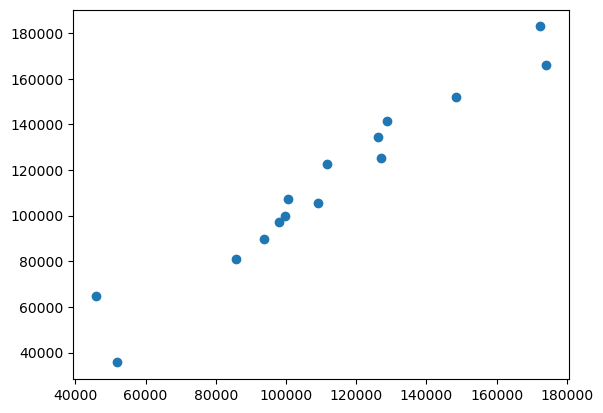

In [57]:
plt.scatter(y_predict, y_test)

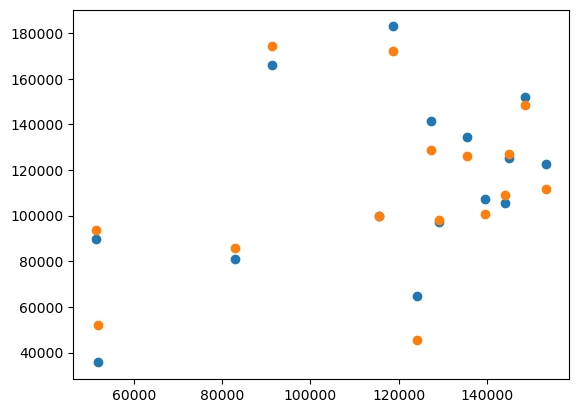

In [62]:
plt.scatter(X_test["Administration"], y_test)
plt.scatter(X_test["Administration"], y_predict)

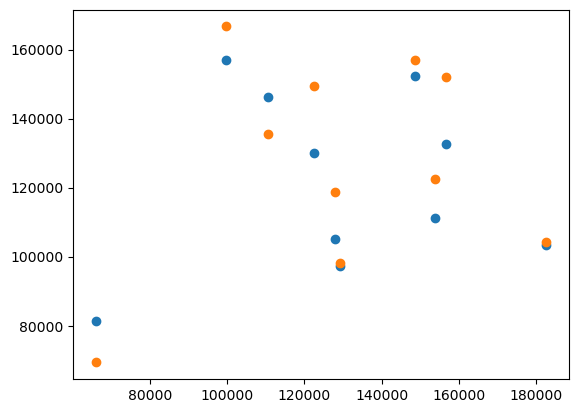

## RSS

In [59]:
import numpy as np
np.sum((y_test.values - y_predict)**2)

1272404325.5038097

In [60]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test.values, y_predict) * len(y_predict)

1272404325.5038097

1458292921.1634684

In [64]:
len(y_predict)

15

10

1458292921.1634684

10

## R Square

In [69]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [65]:
from sklearn.metrics import r2_score
r2_score(y_test, y_predict)

0.9397108063368201

0.7533298848190992

In [73]:
v1 = int(input("Enter value R&D Spend:- "))
v2 = int(input("Enter value Administration:-"))
v3 = int(input("Enter value Marketing Spend:- "))

v4 = int(input("Enter 1 for New York, Enter 2 for Califoria, Enter 3 for Florida"))

if v4 == 1:
    city = "New York"
elif v4 == 2:
    city = "Califoria"
else:
    city = "Florida"

last_arr = np.array([v1,v2,v3,city])
last_arr 


array(['123000', '120000', '120000', 'Califoria'], dtype='<U21')